In [1]:
# import dependencies
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# open dfs
df = pd.read_csv("../data/cleaned/town_level_merged_for_eda.csv")
gdf = gpd.read_file("../data/cleaned/census.geojson")

# ensure types are correct for merging
df["GEOID"] = df["GEOID"].astype(str)
gdf["GEOID"] = gdf["GEOID"].astype(str)

# merge df and gdf
gdf = gdf.merge(df, left_on="GEOID", right_on="GEOID")
gdf.head()

,GEOID,NAME,NAMELSAD,ALAND,AWATER,geometry,town_name,aland_sqm,awater_sqm,town_area_sqm,...,share_infrastructure_protection,share_infrastructure_stormwater,share_other,share_planning,share_structure_protection,funding_per_capita,log_funding_per_capita,funding_per_occupied_unit,log_funding_per_occupied_unit,has_funding
0,5001523500,Eden,Eden town,162970286,2552928,"POLYGON ((-72.66139 44.70192, -72.66084 44.702...",Eden town,162970286,2552928,165523226.0,...,0.000000,1.00000,0.0,0.0,0.0,6.831426,2.058145,16.163321,2.842775,True
1,5002548400,Newfane,Newfane town,102981054,697246,"POLYGON ((-72.7755 42.92638, -72.77376 42.9292...",Newfane town,102981054,697246,103678298.0,...,0.000000,0.00000,0.0,0.0,0.0,615.238017,6.423633,1244.147990,7.127010,True
2,5002560250,Rockingham,Rockingham town,107252397,2011216,"POLYGON ((-72.55798 43.12776, -72.55798 43.128...",Rockingham town,107252397,2011216,109263619.0,...,0.138989,0.23426,0.0,0.0,0.0,89.132014,4.501275,195.286048,5.279573,True
3,5002581400,Westminster,Westminster town,116613918,669527,"POLYGON ((-72.58564 43.02324, -72.58491 43.027...",Westminster town,116613918,669527,117283434.0,...,0.000000,0.00000,0.0,0.0,0.0,18.688131,2.980016,43.649302,3.798839,True
4,5002584850,Windham,Windham town,67581474,211573,"POLYGON ((-72.77335 43.1539, -72.77256 43.1547...",Windham town,67581474,211573,67793053.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [3]:
# show potential outliers for pct_river_corridor and pct_high_risk_NFHL

# Select relevant columns
cols = [
    "town_name",
    "pct_river_corridor",
    "pct_high_risk_NFHL",
    "aland_sqm",
    "awater_sqm",
]

# sort by pct_high_risk_NFHL descending to see the highest values
outliers_nfhl = (
    df[cols].sort_values("pct_high_risk_NFHL", ascending=False).head(15)
)
print("Top towns by pct_high_risk_NFHL:")
display(outliers_nfhl)

# sort by pct_river_corridor descending to see the highest values
outliers_rc = df[cols].sort_values("pct_river_corridor", ascending=False).head(15)
print("Top towns by pct_river_corridor:")
display(outliers_rc)

Top towns by pct_high_risk_NFHL:


,town_name,pct_river_corridor,pct_high_risk_NFHL,aland_sqm,awater_sqm
25,Brandon town,9.304930,22.009892,102913148,580731
250,Winooski city,20.139475,19.087063,3576484,236698
50,Colchester town,5.204381,16.096007,94040216,62094186
37,Burlington city,8.667157,15.913886,26684548,13079229
161,Proctor town,12.042715,15.634356,19203951,434228
68,Essex Junction city,14.218977,13.889044,11833863,499088
42,Castleton town,3.259153,13.827421,100858959,8939647
70,Fair Haven town,6.330155,13.421254,45347088,1843176
232,West Haven town,5.843710,13.345403,72838833,1675200
69,Essex town,5.637135,11.796985,88941934,817671


Top towns by pct_river_corridor:


,town_name,pct_river_corridor,pct_high_risk_NFHL,aland_sqm,awater_sqm
250,Winooski city,20.139475,19.087063,3576484,236698
68,Essex Junction city,14.218977,13.889044,11833863,499088
213,Vergennes city,14.034324,0.000000,6359940,199983
240,Weybridge town,13.509111,0.000000,44282021,1217222
161,Proctor town,12.042715,15.634356,19203951,434228
174,Rutland city,10.405589,10.942258,19562139,302417
12,Barre city,9.791221,9.184907,10327567,83565
25,Brandon town,9.304930,22.009892,102913148,580731
132,Montpelier city,8.929177,7.313728,26048132,504947
37,Burlington city,8.667157,15.913886,26684548,13079229


In [4]:
# list of key variables to focus on in EDA
key_vars = [
    "has_funding",
    "total_population",
    "pct_river_corridor",
    "pct_high_risk_NFHL",
    "median_income",
    "percent_elderly",
    "median_year_house_built",
    "pct_no_vehicle",
    "pct_renter_occupied",
    "pct_bachelors_or_higher",
    "pct_below_poverty",
    "percent_with_disability",
    "pct_mobile_home",
    "funding_per_capita",
    "log_funding_per_capita",
    "funding_per_occupied_unit",
    "log_funding_per_occupied_unit",
    "claims_paid_per_capita",
    "current_insurance_penetration",
]

<Figure size 1000x600 with 0 Axes>

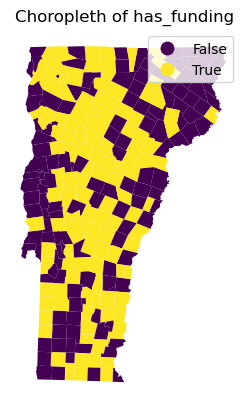

<Figure size 1000x600 with 0 Axes>

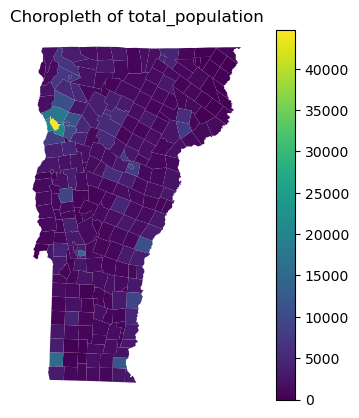

<Figure size 1000x600 with 0 Axes>

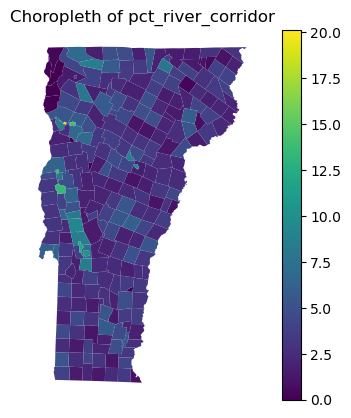

<Figure size 1000x600 with 0 Axes>

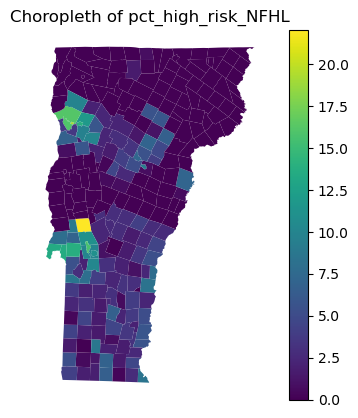

<Figure size 1000x600 with 0 Axes>

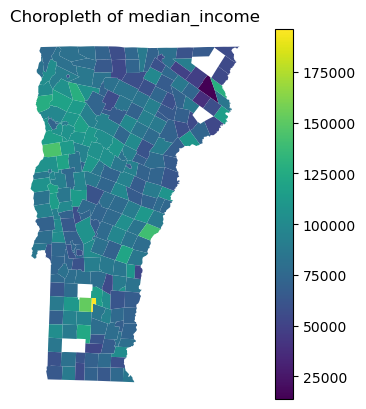

<Figure size 1000x600 with 0 Axes>

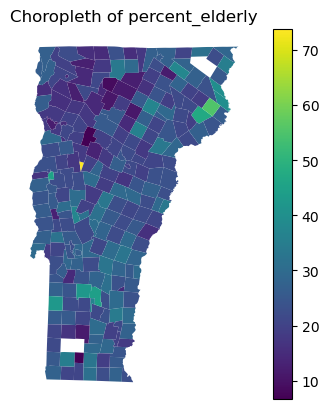

<Figure size 1000x600 with 0 Axes>

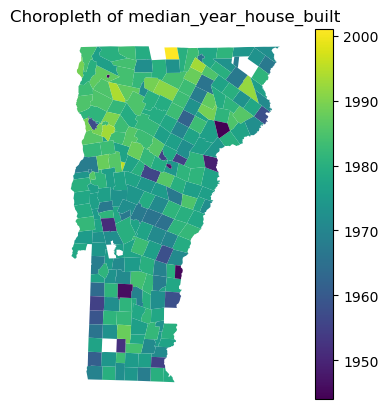

<Figure size 1000x600 with 0 Axes>

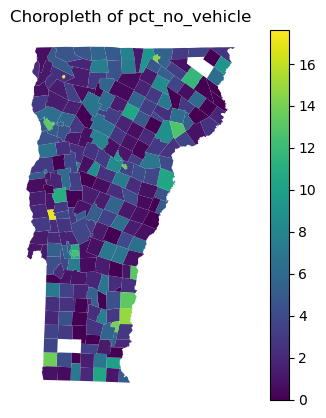

<Figure size 1000x600 with 0 Axes>

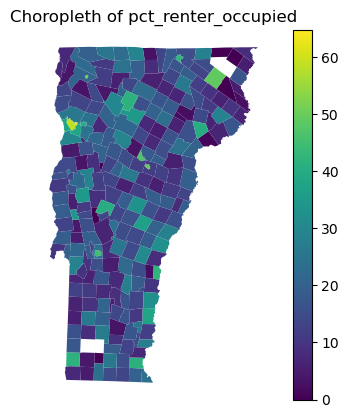

<Figure size 1000x600 with 0 Axes>

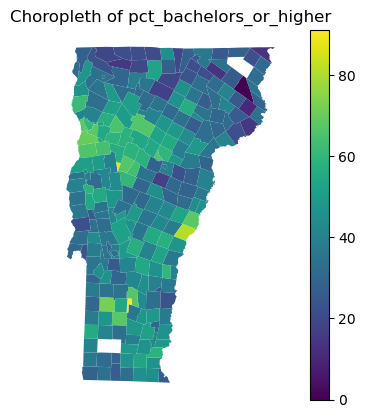

<Figure size 1000x600 with 0 Axes>

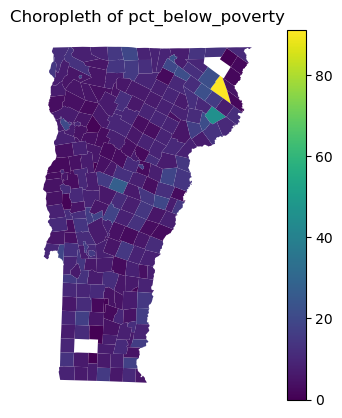

<Figure size 1000x600 with 0 Axes>

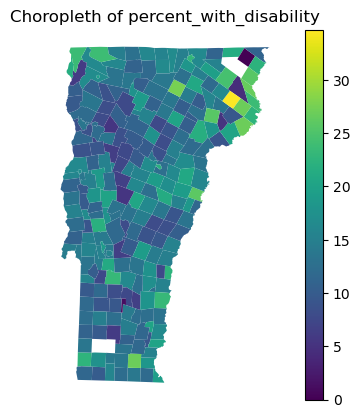

<Figure size 1000x600 with 0 Axes>

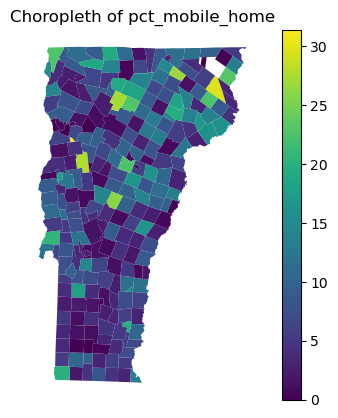

<Figure size 1000x600 with 0 Axes>

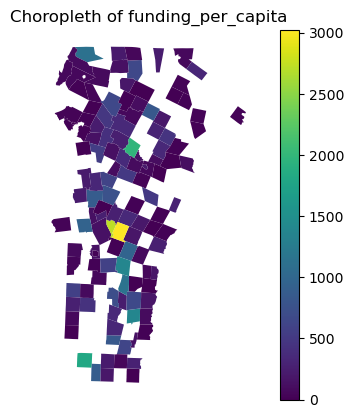

<Figure size 1000x600 with 0 Axes>

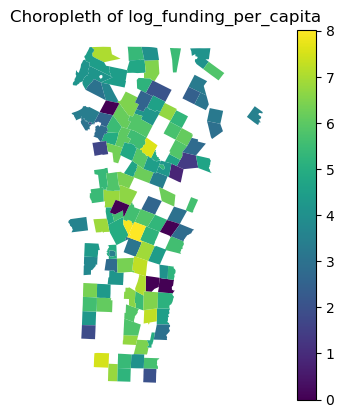

<Figure size 1000x600 with 0 Axes>

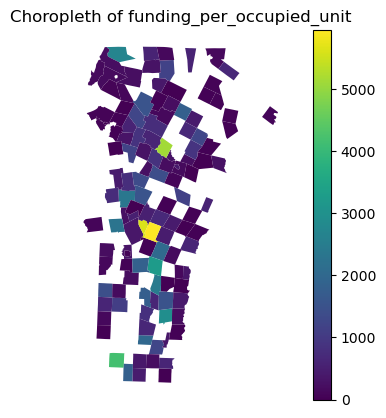

<Figure size 1000x600 with 0 Axes>

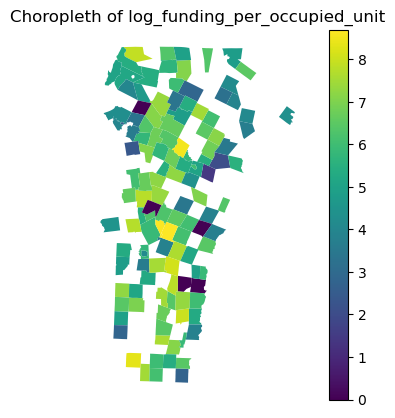

<Figure size 1000x600 with 0 Axes>

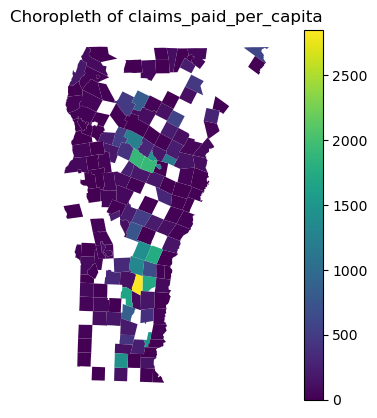

<Figure size 1000x600 with 0 Axes>

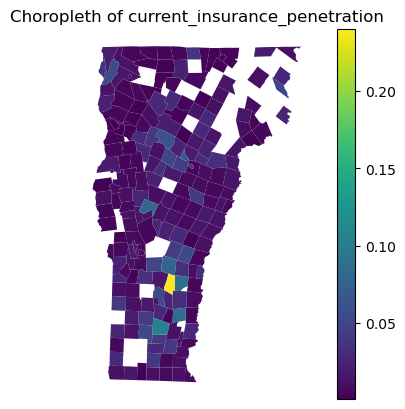

In [5]:
# plot choropleths for key variables
for var in key_vars:
    plt.figure(figsize=(10, 6))
    gdf.plot(column=var, cmap="viridis", legend=True)
    plt.title(f"Choropleth of {var}")
    plt.axis("off")
    plt.show()

In [6]:
# time-based columns
time_cols = [
    "pre_2011",
    "2011_2022",
    "2023_plus",
    "pre_2011_nfip_claims",
    "2011_2022_nfip_claims",
    "2023_plus_nfip_claims",
    "pre_2011_nfip_claims_count",
    "2011_2022_nfip_claims_count",
    "2023_plus_nfip_claims_count"
]

<Figure size 1000x600 with 0 Axes>

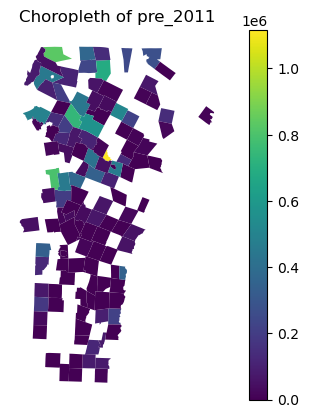

<Figure size 1000x600 with 0 Axes>

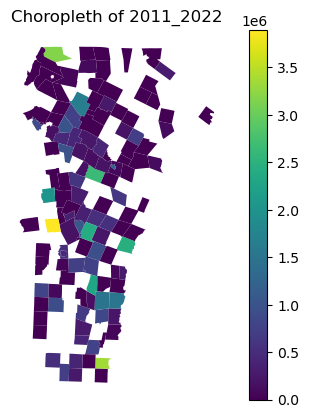

<Figure size 1000x600 with 0 Axes>

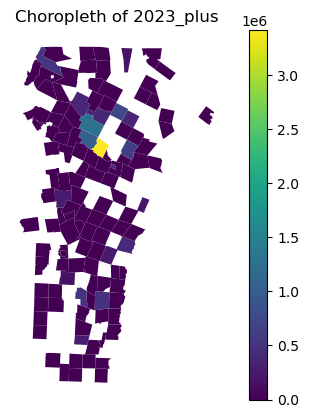

<Figure size 1000x600 with 0 Axes>

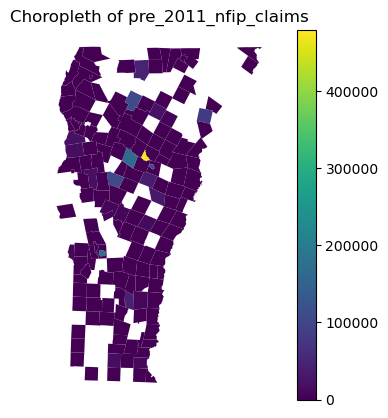

<Figure size 1000x600 with 0 Axes>

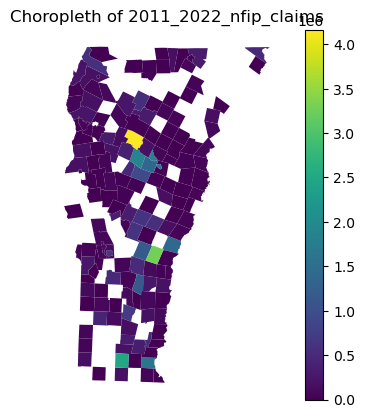

<Figure size 1000x600 with 0 Axes>

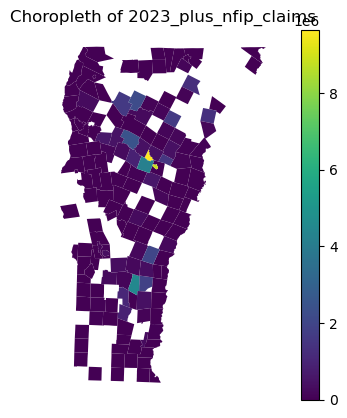

<Figure size 1000x600 with 0 Axes>

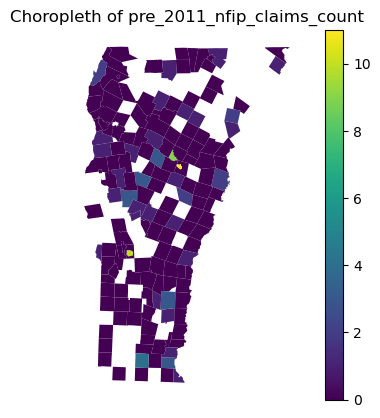

<Figure size 1000x600 with 0 Axes>

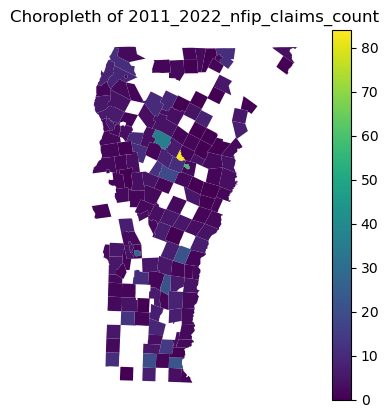

<Figure size 1000x600 with 0 Axes>

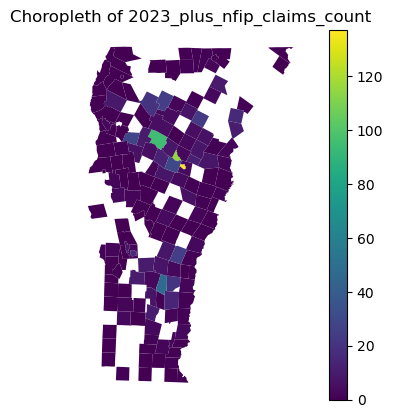

In [7]:
# choropleths for time-based columns
for col in time_cols:
    plt.figure(figsize=(10, 6))
    gdf.plot(column=col, cmap="viridis", legend=True)
    plt.title(f"Choropleth of {col}")
    plt.axis("off")
    plt.show()